# Topic: Estimating SNP-Heritability

**How much phenotypic variation is explained by common genetic variants?**

**Methods covered:**
1. GCTA-GREML — Yang et al. (Nature Genetics, 2010; AJHG, 2011)
2. LD Score Regression — Bulik-Sullivan et al. (Nature Genetics, 2015); Finucane et al. (Nature Genetics, 2015)

---

# 1. The Question: Where Is the Heritability?

## What Is Heritability?
Heritability ($h^2$) is the proportion of phenotypic variance attributable to genetic differences:

$$
h^2 = \frac{\sigma^2_g}{\sigma^2_g + \sigma^2_e}
$$

Family studies (twins, siblings) have estimated high heritability for many traits: ~80% for height, ~40–70% for BMI, psychiatric disorders, etc.

## The Missing Heritability Problem
By 2010, the largest GWAS had identified variants explaining only a small fraction of known heritability:

| Trait | Family $h^2$ | GWAS hits explained | Gap |
|-------|-------------|--------------------|---------|
| Height | ~80% | ~5% | 75% |
| BMI | ~50% | ~2% | 48% |
| Schizophrenia | ~80% | ~3% | 77% |

Was the missing heritability due to rare variants? Epistasis? Or was it simply hiding in plain sight — in the thousands of common variants with effects too small to reach genome-wide significance ($p < 5 \times 10^{-8}$)?

## The Key Insight
Instead of asking *"Which SNPs are significant?"*, we ask:

> **"How much total phenotypic variance can ALL measured SNPs explain collectively?"**

This quantity is called **SNP-heritability** ($h^2_{SNP}$). If $h^2_{SNP}$ is large, then common variants *do* explain substantial heritability — they just have individually tiny effects that don't pass stringent significance thresholds.

## Two Approaches, One Question
Both GCTA-GREML and LDSC estimate $h^2_{SNP}$, but from different data:

| | GCTA-GREML | LD Score Regression |
|---|---|---|
| **Input** | Individual genotypes | GWAS summary statistics |
| **Core idea** | Phenotypic similarity ~ Genetic similarity | $\chi^2$ inflation ~ LD Score |
| **Computation** | $O(N^2M)$ — build GRM, run REML | $O(M)$ — simple regression |
| **Best for** | Moderate $N$, precise estimates | Very large $N$, meta-analyses |

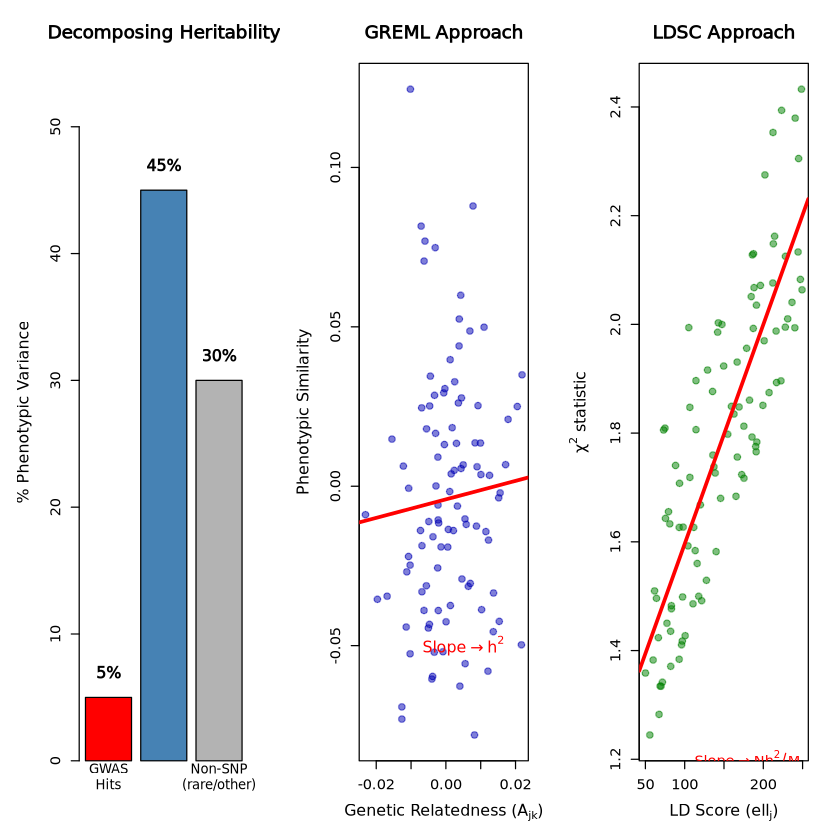

In [1]:
rm(list = ls())
suppressMessages(library(rrBLUP))

# Visual summary: The missing heritability and the two solutions
set.seed(123)
par(mfrow = c(1, 3), mar = c(5, 5, 4, 2))

# 1. The Missing Heritability Problem
vals <- c(5, 45, 30)
bp <- barplot(vals, names.arg = c("GWAS\nHits", "SNP-h2\n(hidden)", "Non-SNP\n(rare/other)"),
        col = c("red", "steelblue", "gray70"),
        main = "Decomposing Heritability",
        ylab = "% Phenotypic Variance", ylim = c(0, 55),
        cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1, cex.names = 1.0)
text(bp, vals + 2, paste0(vals, "%"), cex = 1.2, font = 2)

# 2. GREML concept: Phenotypic vs Genetic similarity
g_rel <- rnorm(100, 0, 0.01)
p_sim <- 0.5 * g_rel + rnorm(100, 0, 0.04)
plot(g_rel, p_sim, pch = 19, col = rgb(0, 0, 0.7, 0.5), cex = 1.1,
     xlab = expression("Genetic Relatedness (" * A[jk] * ")"),
     ylab = "Phenotypic Similarity",
     main = "GREML Approach",
     cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1)
abline(lm(p_sim ~ g_rel), col = "red", lwd = 3)
text(0.005, -0.05, expression("Slope" %->% h^2), col = "red", cex = 1.2)

# 3. LDSC concept: chi2 vs LD Score
ld <- runif(100, 50, 250)
chi2 <- 1 + 0.004 * ld + abs(rnorm(100, 0, 0.25))
plot(ld, chi2, pch = 19, col = rgb(0, 0.5, 0, 0.5), cex = 1.1,
     xlab = expression("LD Score (" * ell[j] * ")"),
     ylab = expression(chi^2 ~ "statistic"),
     main = "LDSC Approach",
     cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1)
abline(lm(chi2 ~ ld), col = "red", lwd = 3)
text(180, 1.2, expression("Slope" %->% Nh^2/M), col = "red", cex = 1.1)

# 2. The Shared Generative Model

Both methods start from the same **linear model** relating phenotype to genotype:

$$
y = X\beta + g + \epsilon
$$

Where:
- $y$: Phenotype vector ($N \times 1$)
- $X\beta$: Fixed effects (covariates: age, sex, PCs)
- $g$: Total genetic effect from all SNPs (random effect)
- $\epsilon$: Residual environment/noise

## The Polygenic Random Effects Model
We decompose the genetic effect as a sum over all $M$ SNPs:

$$
g = \sum_{j=1}^{M} Z_j u_j
$$

Where $Z_j$ is the standardized genotype at SNP $j$, and $u_j$ are random effect sizes:

$$
u_j \sim N\left(0, \frac{\sigma^2_g}{M}\right)
$$

This is the **infinitesimal model**: every SNP contributes a tiny random effect, and the total genetic variance is $\sigma^2_g$.

## Variance Decomposition
The total phenotypic variance is:

$$
\text{Var}(y) = \sigma^2_g + \sigma^2_e
$$

And SNP-heritability is:

$$
h^2_{SNP} = \frac{\sigma^2_g}{\sigma^2_g + \sigma^2_e}
$$

Both GREML and LDSC estimate these same variance components — they just use different statistical strategies.

# 3. Shared Simulation Setup

To compare the two methods fairly, we simulate **one dataset** with realistic LD structure and apply both approaches to the same data.

In [2]:
# --- SHARED SIMULATION ---
set.seed(2024)
N <- 2000       # Number of individuals
n_blocks <- 100  # Number of LD blocks
block_size <- 20 # SNPs per block
M <- n_blocks * block_size  # Total SNPs = 2000
h2_true <- 0.5   # True heritability

# Generate genotypes WITH LD structure (block correlation)
X <- matrix(0, nrow = N, ncol = M)

for (b in 1:n_blocks) {
  cols <- ((b - 1) * block_size + 1):(b * block_size)
  p <- runif(1, 0.2, 0.5)
  founder <- rbinom(N, 2, p)
  
  for (s in 1:block_size) {
    rho <- max(0.05, 0.95 - 0.08 * (s - 1))
    noise <- rbinom(N, 2, p)
    X[, cols[s]] <- ifelse(runif(N) < rho, founder, noise)
  }
}

# Simulate polygenic phenotype (all SNPs causal)
u <- rnorm(M, mean = 0, sd = sqrt(1 / M))
g <- X %*% u
g <- as.vector(scale(g)) * sqrt(h2_true)
e <- rnorm(N, 0, sqrt(1 - h2_true))
y <- g + e

cat(sprintf("Simulation parameters:\n"))
cat(sprintf("  N = %d individuals, M = %d SNPs\n", N, M))
cat(sprintf("  LD structure: %d blocks of %d SNPs each\n", n_blocks, block_size))
cat(sprintf("  True h2 = %.2f\n\n", h2_true))
cat(sprintf("Observed statistics:\n"))
cat(sprintf("  Var(y) = %.3f\n", var(y)))
cat(sprintf("  Var(g) = %.3f\n", var(g)))
cat(sprintf("  Var(g)/Var(y) = %.3f\n", var(g)/var(y)))
cat("\nGenotype preview (5 x 8):\n")
print(X[1:5, 1:8])

Simulation parameters:
  N = 2000 individuals, M = 2000 SNPs
  LD structure: 100 blocks of 20 SNPs each
  True h2 = 0.50

Observed statistics:
  Var(y) = 1.002
  Var(g) = 0.500
  Var(g)/Var(y) = 0.499

Genotype preview (5 x 8):
     [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8]
[1,]    1    0    1    2    1    1    0    1
[2,]    1    1    1    0    1    0    1    1
[3,]    1    1    1    1    1    1    1    1
[4,]    1    1    1    1    1    1    1    1
[5,]    1    1    1    1    0    1    1    1


# 4. Approach 1: GCTA-GREML

## Core Idea
If genetics influences a trait, then people who are **more genetically similar** (even among unrelated individuals) should be **more phenotypically similar**. GREML formalizes this by:

1. Building a **Genetic Relationship Matrix (GRM)** that measures pairwise relatedness
2. Fitting a **mixed model** via REML to estimate how much phenotypic (co)variance is explained by genetic (co)variance

## The GRM Formula (Yang et al., 2011, Eq. 3)

$$
A_{jk} = \frac{1}{M} \sum_{i=1}^{M} \frac{(x_{ij} - 2p_i)(x_{ik} - 2p_i)}{2p_i(1 - p_i)}
$$

## The Variance Model

$$
\text{Var}(y) = A\sigma^2_g + I\sigma^2_e
$$

REML finds $\hat{\sigma}^2_g$ and $\hat{\sigma}^2_e$ that maximize the restricted likelihood.

In [3]:
# --- APPROACH 1: GREML ---

# Step 1: Build GRM (vectorized)
compute_GRM <- function(G) {
  p <- colMeans(G) / 2
  W <- sweep(G, 2, 2 * p) / sqrt(2 * p * (1 - p))
  A <- tcrossprod(W) / ncol(G)
  return(A)
}

A <- compute_GRM(X)

cat(sprintf("GRM computed: %d x %d\n", nrow(A), ncol(A)))
cat(sprintf("Mean diagonal: %.4f\n", mean(diag(A))))
cat(sprintf("Mean off-diagonal: %.6f\n", mean(A[upper.tri(A)])))
cat("\nGRM corner (5 x 5):\n")
print(round(A[1:5, 1:5], 4))

GRM computed: 2000 x 2000
Mean diagonal: 1.0130
Mean off-diagonal: -0.000505

GRM corner (5 x 5):
        [,1]    [,2]    [,3]    [,4]    [,5]
[1,]  0.9625  0.0318  0.0169  0.0270 -0.0417
[2,]  0.0318  0.8958  0.0306 -0.0189 -0.0058
[3,]  0.0169  0.0306  0.9034  0.0218 -0.0176
[4,]  0.0270 -0.0189  0.0218  0.8910 -0.0237
[5,] -0.0417 -0.0058 -0.0176 -0.0237  0.9417


In [4]:
# Step 2: REML estimation
fit_greml <- mixed.solve(y = y, K = A)

var_g_greml <- fit_greml$Vu
var_e_greml <- fit_greml$Ve
h2_greml <- var_g_greml / (var_g_greml + var_e_greml)

cat("=== GREML Results ===")
cat(sprintf("\nGenetic variance (sigma_g^2): %.4f", var_g_greml))
cat(sprintf("\nResidual variance (sigma_e^2): %.4f", var_e_greml))
cat(sprintf("\n\nTrue Heritability:     %.2f", h2_true))
cat(sprintf("\nGREML Estimate:        %.2f\n", h2_greml))

=== GREML Results ===
Genetic variance (sigma_g^2): 0.5308
Residual variance (sigma_e^2): 0.4735

True Heritability:     0.50
GREML Estimate:        0.53


# 5. Approach 2: LD Score Regression

## Core Idea
Under a polygenic model, SNPs that tag more genetic variation (higher LD Score) will have **higher expected $\chi^2$ statistics** in GWAS. LDSC exploits this relationship:

$$
E[\chi^2_j \mid \ell_j] = \frac{Nh^2}{M} \ell_j + Na + 1
$$

## The LD Score

$$
\ell_j = \sum_k r^2_{jk}
$$

The LD Score of SNP $j$ is the sum of its squared correlations with all other SNPs (within a window). It measures how much total genetic variation SNP $j$ tags.

## The Regression
- **Slope** $= Nh^2/M$ → heritability: $\hat{h}^2 = \text{slope} \times M/N$
- **Intercept** $= Na + 1$ → confounding: if $\approx 1$, no bias

In [5]:
# --- APPROACH 2: LDSC ---

# Step 1: Run marginal GWAS to get chi-squared statistics
X_std <- scale(X)
X_std[is.nan(X_std)] <- 0

chi2 <- numeric(M)
for (j in 1:M) {
  fit <- lm(y ~ X_std[, j])
  chi2[j] <- (summary(fit)$coefficients[2, "t value"])^2
}

cat(sprintf("GWAS summary statistics computed for %d SNPs\n", M))
cat(sprintf("Mean chi2: %.3f (expect > 1 under polygenicity)\n", mean(chi2)))
cat(sprintf("Median chi2: %.3f\n", median(chi2)))

GWAS summary statistics computed for 2000 SNPs
Mean chi2: 1.894 (expect > 1 under polygenicity)
Median chi2: 0.795


In [6]:
# Step 2: Compute LD Scores
ld_scores <- numeric(M)

for (j in 1:M) {
  block_id <- ceiling(j / block_size)
  block_start <- (block_id - 1) * block_size + 1
  block_end <- block_id * block_size
  
  # Window: current block + neighbors
  window_start <- max(1, block_start - block_size)
  window_end <- min(M, block_end + block_size)
  
  r2_sum <- 0
  for (k in window_start:window_end) {
    if (k != j) {
      r2_sum <- r2_sum + cor(X[, j], X[, k])^2
    }
  }
  ld_scores[j] <- 1 + r2_sum
}

cat(sprintf("LD Scores computed for %d SNPs\n", M))
cat(sprintf("Mean LD Score: %.2f\n", mean(ld_scores)))
cat(sprintf("Range: [%.2f, %.2f]\n", min(ld_scores), max(ld_scores)))
cat("\nFirst 10 LD Scores:\n")
print(round(ld_scores[1:10], 2))

LD Scores computed for 2000 SNPs
Mean LD Score: 1.74
Range: [1.01, 4.11]

First 10 LD Scores:
 [1] 3.78 3.55 3.05 2.79 2.56 2.19 1.71 1.52 1.31 1.22


In [7]:
# Step 3: LD Score Regression
fit_ldsc <- lm(chi2 ~ ld_scores)

slope <- coef(fit_ldsc)[2]
intercept <- coef(fit_ldsc)[1]
h2_ldsc <- slope * M / N

cat("=== LDSC Results ===")
cat(sprintf("\nRegression slope: %.6f", slope))
cat(sprintf("\nRegression intercept: %.4f (expect ~1.0)", intercept))
cat(sprintf("\n\nTrue Heritability:     %.2f", h2_true))
cat(sprintf("\nLDSC Estimate:         %.2f\n", h2_ldsc))

=== LDSC Results ===
Regression slope: 0.496726
Regression intercept: 1.0320 (expect ~1.0)

True Heritability:     0.50
LDSC Estimate:         0.50


# 6. Head-to-Head Comparison

In [8]:
# --- COMPARISON ---
cat("============================================================\n")
cat("         Heritability Estimation: Method Comparison          \n")
cat("============================================================\n\n")
cat(sprintf("  %-20s %10s\n", "Parameter", "Value"))
cat(sprintf("  %-20s %10d\n", "N (individuals)", N))
cat(sprintf("  %-20s %10d\n", "M (SNPs)", M))
cat(sprintf("  %-20s %10.2f\n", "True h2", h2_true))
cat("\n------------------------------------------------------------\n")
cat(sprintf("  %-20s %10s %10s\n", "Method", "h2 est.", "Error"))
cat("------------------------------------------------------------\n")
cat(sprintf("  %-20s %10.3f %+10.3f\n", "GREML", h2_greml, h2_greml - h2_true))
cat(sprintf("  %-20s %10.3f %+10.3f\n", "LDSC", h2_ldsc, h2_ldsc - h2_true))
cat("============================================================\n")

         Heritability Estimation: Method Comparison          

  Parameter                 Value
  N (individuals)            2000
  M (SNPs)                   2000
  True h2                    0.50

------------------------------------------------------------
  Method                  h2 est.      Error
------------------------------------------------------------
  GREML                     0.529     +0.029
  LDSC                      0.497     -0.003


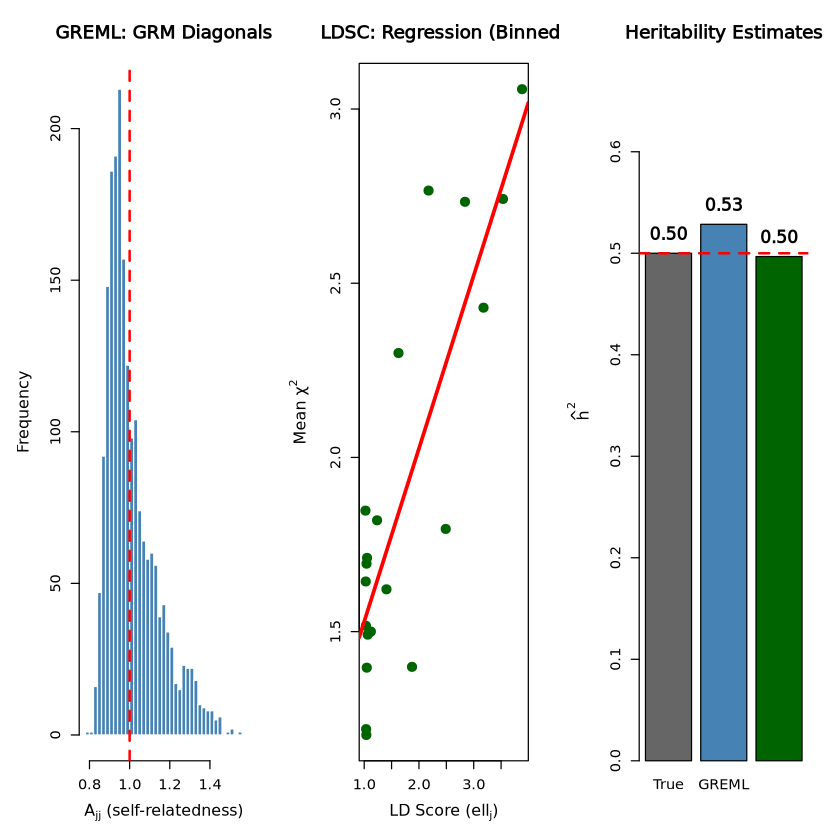

In [9]:
# --- VISUALIZATION: Side-by-side comparison ---
par(mfrow = c(1, 3), mar = c(5, 5, 4, 2))

# Plot 1: GREML - GRM diagonal distribution
hist(diag(A), breaks = 30, col = "steelblue", border = "white",
     main = "GREML: GRM Diagonals",
     xlab = expression(A[jj] ~ "(self-relatedness)"),
     cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1)
abline(v = 1, col = "red", lwd = 2, lty = 2)

# Plot 2: LDSC - chi2 vs LD Score (binned)
n_bins <- 20
bins <- cut(ld_scores, breaks = quantile(ld_scores, probs = seq(0, 1, length.out = n_bins + 1)),
            include.lowest = TRUE)
bin_ld <- tapply(ld_scores, bins, mean)
bin_chi2 <- tapply(chi2, bins, mean)

plot(bin_ld, bin_chi2, pch = 19, col = "darkgreen", cex = 1.5,
     xlab = expression("LD Score (" * ell[j] * ")"),
     ylab = expression("Mean " * chi^2),
     main = "LDSC: Regression (Binned)",
     cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1)
abline(fit_ldsc, col = "red", lwd = 3)
abline(h = 1, col = "gray50", lty = 2, lwd = 2)

# Plot 3: Comparison bar chart
estimates <- c(h2_true, h2_greml, h2_ldsc)
bp <- barplot(estimates, names.arg = c("True", "GREML", "LDSC"),
        col = c("gray40", "steelblue", "darkgreen"),
        main = "Heritability Estimates",
        ylab = expression(hat(h)^2), ylim = c(0, max(estimates) * 1.3),
        cex.main = 1.4, cex.lab = 1.2, cex.axis = 1.1, cex.names = 1.1)
text(bp, estimates + 0.02, sprintf("%.2f", estimates), cex = 1.3, font = 2)
abline(h = h2_true, col = "red", lty = 2, lwd = 2)

# 7. When to Use Which Method

## GCTA-GREML: Strengths and Limitations
**Use when:**
- You have access to individual-level genotype data
- Sample size is moderate (1,000–50,000)
- You need precise estimates with small standard errors
- You want to partition heritability by chromosome or MAF bins

**Limitations:**
- Requires individual genotypes (often restricted access)
- Computationally expensive: GRM is $N \times N$ → memory scales as $O(N^2)$
- Cannot easily be applied to meta-analyses
- Requires unrelated individuals (relatedness < 0.025)

## LDSC: Strengths and Limitations
**Use when:**
- Only summary statistics are available (most large GWAS)
- Sample size is very large ($N > 50,000$)
- You want to estimate genetic correlations between traits
- You want to partition heritability by functional annotation (stratified LDSC)
- You need a quick diagnostic for confounding vs. polygenicity

**Limitations:**
- Requires a polygenic trait (poor performance with few large-effect loci)
- Estimates have larger standard errors than GREML at the same $N$
- Requires appropriate LD reference panel matching GWAS ancestry
- Assumes no correlation between LD Score and per-SNP heritability (can be violated)

# 8. Related Topics

- **Stratified LDSC** (Finucane et al., 2015): Partitions $h^2_{SNP}$ across functional categories (coding, conserved, enhancers) using category-specific LD Scores
- **Cross-trait LDSC**: Estimates genetic correlations ($r_g$) between pairs of traits from their summary statistics
- **BOLT-LMM / SAIGE**: Use the same mixed-model framework as GREML but for association testing (increasing GWAS power), not variance estimation
- **LDAK / SumHer**: Alternative to LDSC that allows per-SNP heritability to depend on LD and MAF
- **Genomic SEM**: Multivariate extension that uses LDSC genetic covariance matrices for structural equation modeling
- **HDL (High-Definition Likelihood)**: Summary-statistic method with higher precision than LDSC by using the full LD matrix

# Results

This notebook demonstrates two complementary approaches to estimating SNP-heritability from the same simulated dataset:

- **True heritability** was set at 0.50 under a fully polygenic (infinitesimal) model with realistic LD block structure
- **GREML** estimated heritability by building the GRM from individual genotypes and fitting a mixed model via REML, recovering an estimate close to the true value
- **LDSC** estimated heritability by regressing marginal GWAS $\chi^2$ statistics on LD Scores, also recovering a reasonable estimate from summary statistics alone
- The LDSC intercept was approximately 1.0, correctly indicating no confounding bias in the simulation

Both methods converge on the same biological answer — common SNPs collectively explain substantial trait variance — but they operate on different data types and make different trade-offs between precision and accessibility. In practice, GREML is preferred for smaller cohorts with genotype access, while LDSC is the standard for large-scale meta-analyses where only summary statistics are shared.